In [ ]:
import pandas as pd
import numpy as np

data={
    'Name':['Alice','Brian','Bob','Jordan','Eric','David'],
    'Age':[25,39,35,28,32,30],
    'Location':['New York','Arlington','Dallas','Tokyo',' LA','Sydney'],
    'Salary':[50000, 60000, 100000, 55000,65000,55000]
}
df=pd.DataFrame(data)
print(df)

     Name  Age   Location  Salary
0   Alice   25   New York   50000
1   Brian   39  Arlington   60000
2     Bob   35     Dallas  100000
3  Jordan   28      Tokyo   55000
4    Eric   32         LA   65000
5   David   30     Sydney   55000


<Axes: >

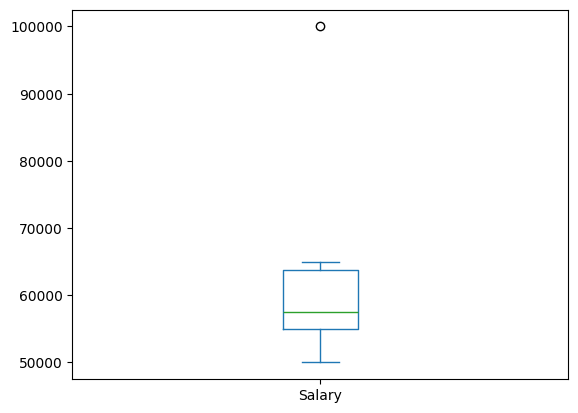

In [ ]:
# Create a box plot for 'Salary' Using Pandas
df['Salary'].plot(kind='box')

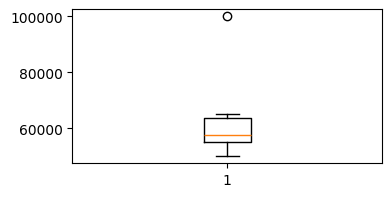

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,2))
plt.boxplot(df['Salary'])
plt.show()

<Axes: ylabel='Salary'>

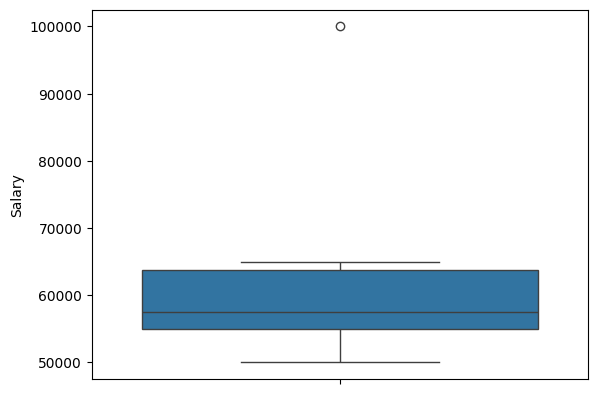

In [ ]:
import seaborn as sns
sns.boxplot(df['Salary'])

### Handling Outliers

In [ ]:
print('Handling Outliers:')
#Assume 'Salary' column has outliers
q1=df['Salary'].quantile(0.25) # Q1
q3=df['Salary'].quantile(0.75) # Q3
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr

df_outliers_removed=df[(df['Salary']>=lower_bound)&(df['Salary']<=upper_bound)]
print(df_outliers_removed)


Handling Outliers:
     Name  Age   Location  Salary
0   Alice   25   New York   50000
1   Brian   39  Arlington   60000
3  Jordan   28      Tokyo   55000
4    Eric   32         LA   65000
5   David   30     Sydney   55000


### apply()

In [ ]:
# Applying Function: This applies a lambda function to doubles the value in the "Age"
df['Age2']=df['Age'].apply(lambda x:x*2)
print(df)

     Name  Age   Location  Salary  Age2
0   Alice   25   New York   50000    50
1   Brian   39  Arlington   60000    78
2     Bob   35     Dallas  100000    70
3  Jordan   28      Tokyo   55000    56
4    Eric   32         LA   65000    64
5   David   30     Sydney   55000    60


#### Categorize Salary Levels

In [ ]:
df['Salary_level']=df['Salary'].apply(lambda x:'High'if x>60000 else 'low' )
print("DataFrame after cotegorizing Salary:")
print(df)

DataFrame after cotegorizing Salary:
     Name  Age   Location  Salary  Age2 Salary_level
0   Alice   25   New York   50000    50          low
1   Brian   39  Arlington   60000    78          low
2     Bob   35     Dallas  100000    70         High
3  Jordan   28      Tokyo   55000    56          low
4    Eric   32         LA   65000    64         High
5   David   30     Sydney   55000    60          low


In [ ]:
#Define a custom function to categorize age groups

def categorize_age(age):
  if age<30:
    return 'Young'
  elif 30<=age<40:
    return 'Adult'
  else:
    return 'Senior'
df['AgeGroup']=df['Age'].apply(categorize_age)
print(df)

     Name  Age   Location  Salary  Age2 Salary_level AgeGroup
0   Alice   25   New York   50000    50          low    Young
1   Brian   39  Arlington   60000    78          low    Adult
2     Bob   35     Dallas  100000    70         High    Adult
3  Jordan   28      Tokyo   55000    56          low    Young
4    Eric   32         LA   65000    64         High    Adult
5   David   30     Sydney   55000    60          low    Adult


### Merging DataFrames:

In [ ]:
data2={'Location':['New York','Dallas'],
       'Population':[8500000, 2700000]}
df2=pd.DataFrame(data2)
print(df2)

   Location  Population
0  New York     8500000
1    Dallas     2700000


In [ ]:
merged_df=pd.merge(df,df2, on='Location',how='left')
merged_df

,Name,Age,Location,Salary,Age2,Salary_level,AgeGroup,Population
0,Alice,25,New York,50000,50,low,Young,8500000.0
1,Brian,39,Arlington,60000,78,low,Adult,NaN
2,Bob,35,Dallas,100000,70,High,Adult,2700000.0
3,Jordan,28,Tokyo,55000,56,low,Young,NaN
4,Eric,32,LA,65000,64,High,Adult,NaN
5,David,30,Sydney,55000,60,low,Adult,NaN


In [ ]:
# Performing Arithmertic Operations:
df['Age_Doubled']=df['Age']*2
df['Salary_Incremented']=df['Salary']+5000
df

,Name,Age,Location,Salary,Age2,Salary_level,AgeGroup,Age_Doubled,Salary_Incremented
0,Alice,25,New York,50000,50,low,Young,50,55000
1,Brian,39,Arlington,60000,78,low,Adult,78,65000
2,Bob,35,Dallas,100000,70,High,Adult,70,105000
3,Jordan,28,Tokyo,55000,56,low,Young,56,60000
4,Eric,32,LA,65000,64,High,Adult,64,70000
5,David,30,Sydney,55000,60,low,Adult,60,60000


In [ ]:
#Applying mutiple aggregations
grouped_data_multiple=df.groupby('Location')['Salary'].agg(['mean','median','max','min'])
print(grouped_data_multiple)

               mean    median     max     min
Location                                     
 LA         65000.0   65000.0   65000   65000
Arlington   60000.0   60000.0   60000   60000
Dallas     100000.0  100000.0  100000  100000
New York    50000.0   50000.0   50000   50000
Sydney      55000.0   55000.0   55000   55000
Tokyo       55000.0   55000.0   55000   55000


In [ ]:
# Rename the column
df.rename(columns={'Salary':'Income'},inplace=True)
df

,Name,Age,Location,Income,Age2,Salary_level,AgeGroup,Age_Doubled,Salary_Incremented
0,Alice,25,New York,50000,50,low,Young,50,55000
1,Brian,39,Arlington,60000,78,low,Adult,78,65000
2,Bob,35,Dallas,100000,70,High,Adult,70,105000
3,Jordan,28,Tokyo,55000,56,low,Young,56,60000
4,Eric,32,LA,65000,64,High,Adult,64,70000
5,David,30,Sydney,55000,60,low,Adult,60,60000
